In [1]:
from tensorflow.keras.layers import Input,Convolution2D
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [3]:
x_inf_bound_train=np.random.uniform(0,27,len(x_train))
x_sup_bound_train=np.random.uniform(0,27,len(x_train))
y_inf_bound_train=np.random.uniform(0,27,len(x_train))
y_sup_bound_train=np.random.uniform(0,27,len(x_train))

print("x_inf_bound_train :",x_inf_bound_train)
print("x_sup_bound_train :",x_sup_bound_train)
print("y_inf_bound_train :",y_inf_bound_train)
print("y_sup_bound_train :",y_sup_bound_train)



x_inf_bound_train : [ 3.14427722 22.01167922 16.11522136 ...  9.04549427  8.50601217
 23.15268332]
x_sup_bound_train : [18.58750874 22.09720365  0.17403912 ...  8.7124591  25.03468466
 15.58912097]
y_inf_bound_train : [ 7.75245913  6.39042414 16.16686527 ...  8.46881616  7.18078438
 21.48841861]
y_sup_bound_train : [ 8.63475776 15.57785826 26.99356188 ... 16.93135973 12.40045243
  6.87662449]


In [4]:
x_inf_bound_test=np.random.uniform(0,27,len(x_test))
x_sup_bound_test=np.random.uniform(0,27,len(x_test))
y_inf_bound_test=np.random.uniform(0,27,len(x_test))
y_sup_bound_test=np.random.uniform(0,27,len(x_test))

print("x_inf_bound_test :",x_inf_bound_test)
print("x_sup_bound_test :",x_sup_bound_test)
print("y_inf_bound_test :",y_inf_bound_test)
print("y_sup_bound_test :",y_sup_bound_test)

x_inf_bound_test : [ 9.870229    9.87894178 13.12594143 ...  8.37010212  0.7216357
 17.50532235]
x_sup_bound_test : [16.52982593 16.98807549 16.54367988 ... 15.20598556  4.55342106
  2.18119216]
y_inf_bound_test : [15.50733288 20.98639966 25.19524595 ...  0.35124792  6.148914
 26.20745177]
y_sup_bound_test : [ 9.26888968  6.00227274 22.4888106  ... 14.17719993 12.05407392
 16.76096671]


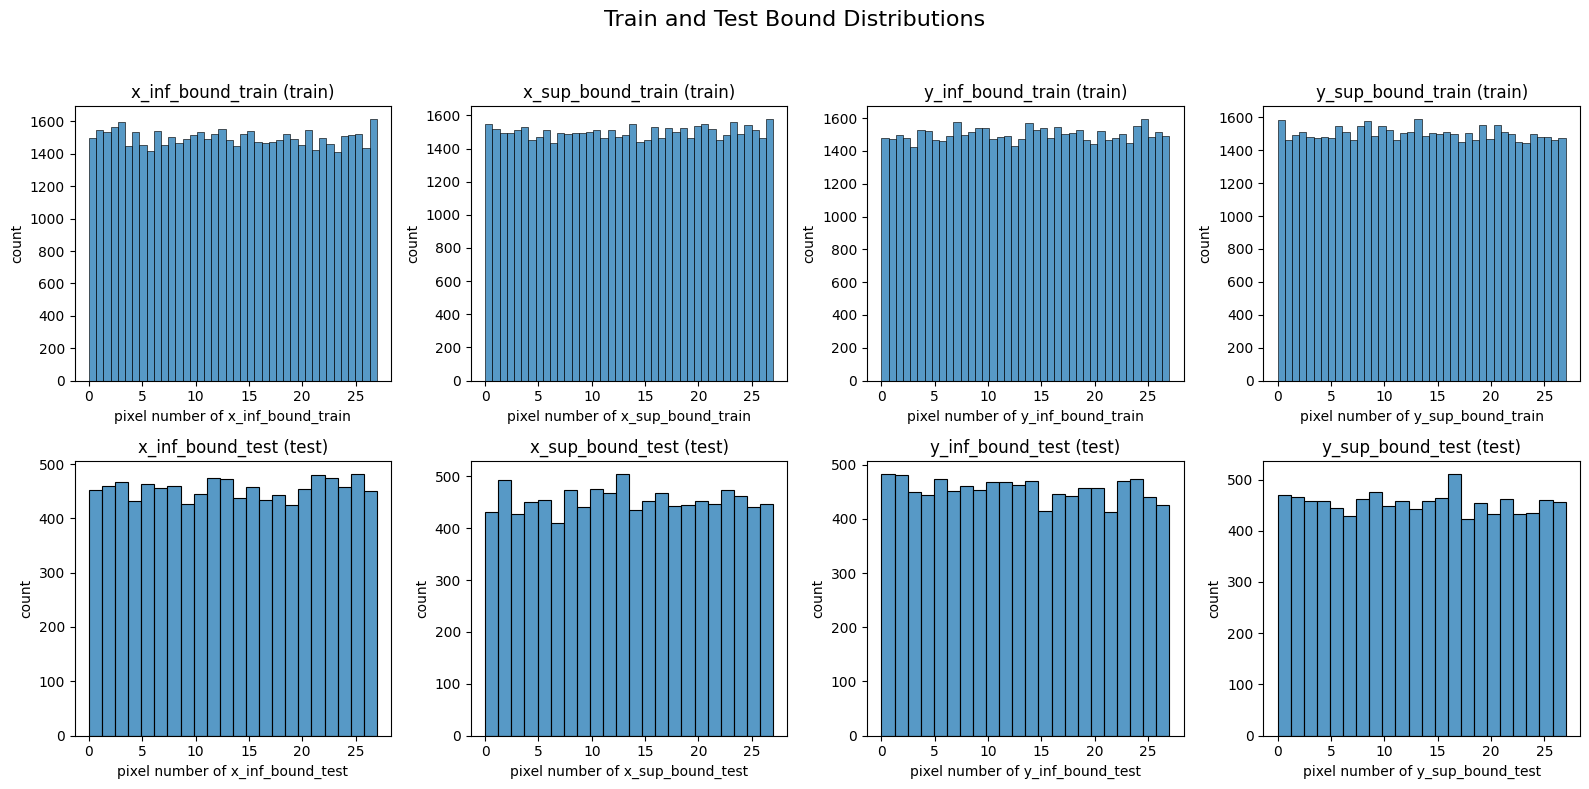

In [5]:

plt.figure(figsize=(16,8))

plt.subplot(2,4,1)
sns.histplot(x_inf_bound_train)
plt.ylabel("count")
plt.xlabel("pixel number of x_inf_bound_train")
plt.title("x_inf_bound_train (train)")

plt.subplot(2,4,2)
sns.histplot(x_sup_bound_train)
plt.ylabel("count")
plt.xlabel("pixel number of x_sup_bound_train")
plt.title("x_sup_bound_train (train)")

plt.subplot(2,4,3)
sns.histplot(y_inf_bound_train)
plt.ylabel("count")
plt.xlabel("pixel number of y_inf_bound_train")
plt.title("y_inf_bound_train (train)")

plt.subplot(2,4,4)
sns.histplot(y_sup_bound_train)
plt.ylabel("count")
plt.xlabel("pixel number of y_sup_bound_train")
plt.title("y_sup_bound_train (train)")

plt.subplot(2,4,5)
sns.histplot(x_inf_bound_test)
plt.ylabel("count")
plt.xlabel("pixel number of x_inf_bound_test")
plt.title("x_inf_bound_test (test)")

plt.subplot(2,4,6)
sns.histplot(x_sup_bound_test)
plt.ylabel("count")
plt.xlabel("pixel number of x_sup_bound_test")
plt.title("x_sup_bound_test (test)")

plt.subplot(2,4,7)
sns.histplot(y_inf_bound_test)
plt.ylabel("count")
plt.xlabel("pixel number of y_inf_bound_test")
plt.title("y_inf_bound_test (test)")

plt.subplot(2,4,8)
sns.histplot(y_sup_bound_test)
plt.ylabel("count")
plt.xlabel("pixel number of y_sup_bound_test")
plt.title("y_sup_bound_test (test)")

plt.suptitle("Train and Test Bound Distributions", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95]) 
plt.show()

In [14]:
n_img=10
crop_img_dim_train = []
for i in range(len(x_train)):

    if x_inf_bound_train[i] > x_sup_bound_train[i]  :
        x_low, x_high = round(x_sup_bound_train[i]), round(x_inf_bound_train[i]) 
    else:
        x_low, x_high = round(x_inf_bound_train[i]), round(x_sup_bound_train[i])

    if y_inf_bound_train[i] > y_sup_bound_train[i]:
        y_low, y_high = round(y_sup_bound_train[i]), round(y_inf_bound_train[i])
    else:
        y_low, y_high = round(y_inf_bound_train[i]), round(y_sup_bound_train[i])

    crop_img_dim_train.append((x_low, x_high, y_low, y_high))
crop_img_dim_train[:n_img]

[(3, 19, 8, 9),
 (22, 22, 6, 16),
 (0, 16, 16, 27),
 (4, 25, 17, 19),
 (6, 9, 12, 18),
 (1, 10, 14, 22),
 (16, 18, 18, 22),
 (0, 24, 4, 21),
 (9, 24, 6, 13),
 (17, 21, 19, 22)]

In [15]:
crop_img_dim_test = []
for i in range(len(x_test)):

    if x_inf_bound_test[i] > x_sup_bound_test[i]:
        x_low, x_high = round(x_sup_bound_test[i]), round(x_inf_bound_test[i])
    else:
        x_low, x_high = round(x_inf_bound_test[i]), round(x_sup_bound_test[i])


    if y_inf_bound_test[i] > y_sup_bound_test[i]:
        y_low, y_high = round(y_sup_bound_test[i]), round(y_inf_bound_test[i])
    else:
        y_low, y_high = round(y_inf_bound_test[i]), round(y_sup_bound_test[i])


    crop_img_dim_test.append((x_low, x_high, y_low, y_high))
crop_img_dim_test[:n_img]

[(10, 17, 9, 16),
 (10, 17, 6, 21),
 (13, 17, 22, 25),
 (5, 7, 16, 16),
 (14, 26, 10, 23),
 (16, 22, 4, 26),
 (14, 18, 18, 20),
 (17, 22, 4, 11),
 (6, 17, 7, 8),
 (16, 22, 23, 23)]

In [16]:
crop_img_train = []
for i in range(len(crop_img_dim_train)):
    x_low, x_high, y_low, y_high = crop_img_dim_train[i]
    cropped = x_train[i, y_low:y_high, x_low:x_high]  
    crop_img_train.append(cropped)
crop_img_train[:n_img]

[array([[  0,   0,   0,   0,  18, 219, 253, 253, 253, 253, 253, 198, 182,
         247, 241,   0]], dtype=uint8),
 array([], shape=(10, 0), dtype=uint8),
 array([[  0,   0,   0,   0, 119, 177, 177, 177, 177, 177,  98,  56,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0, 

In [17]:
crop_img_test = []
for i in range(len(crop_img_dim_test)):
    x_low, x_high, y_low, y_high = crop_img_dim_train[i]
    cropped = x_train[i, y_low:y_high, x_low:x_high]  
    crop_img_test.append(cropped)
crop_img_test[:n_img]

[array([[  0,   0,   0,   0,  18, 219, 253, 253, 253, 253, 253, 198, 182,
         247, 241,   0]], dtype=uint8),
 array([], shape=(10, 0), dtype=uint8),
 array([[  0,   0,   0,   0, 119, 177, 177, 177, 177, 177,  98,  56,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0, 

C:\Users\moonl\AppData\Local\Temp\ipykernel_18016\54307612.py:4: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(crop_img_train[i])


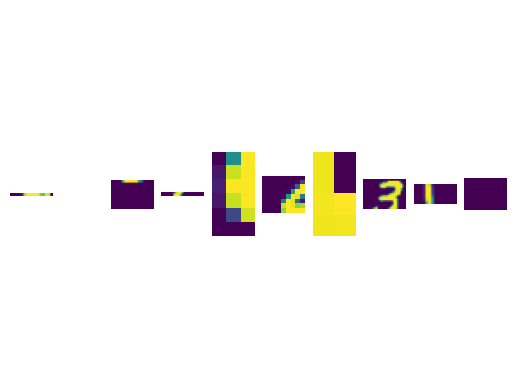

In [10]:
for i in range(n_img):
    plt.subplot(1,n_img,i+1)
    plt.imshow(crop_img_train[i])
    plt.axis("off") 

C:\Users\moonl\AppData\Local\Temp\ipykernel_18016\231618034.py:3: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(crop_img_test[i])


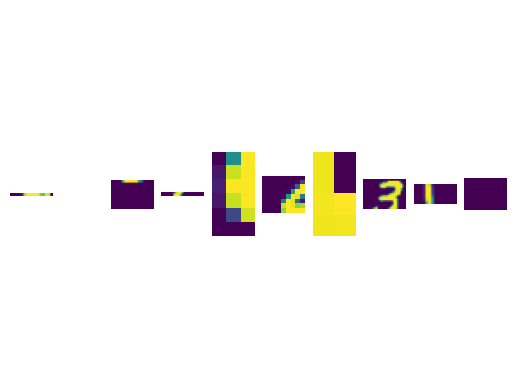

In [11]:
for i in range(n_img):
    plt.subplot(1,n_img,i+1)
    plt.imshow(crop_img_test[i])
    plt.axis("off") 